In [1]:
import sys
from pathlib import Path
import torch
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import OmegaConf

sys.path.insert(0, "/home/akashmanna/ws/probe3d")

In [2]:
with initialize(version_base=None, config_path="../configs"):
    cfg = compose(config_name="detection_training")

In [3]:
model   = instantiate(cfg.backbone)
probe   = instantiate(cfg.probe, feat_dim=model.feat_dim)


/home/akashmanna/miniconda3/envs/vlg_eval312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using cache found in /home/akashmanna/.cache/torch/hub/facebookresearch_dinov2_main
/home/akashmanna/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/akashmanna/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/akashmanna/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [4]:
chkpt= torch.load("//home/akashmanna/ws/probe3d/detection_exps/07072026-1317_dinov2_vitb14_14_11_dense-cls_detection_dpt_10_1.50_5.00e-04_0.00e+00_1_KITTI3D_KITTI3D/checkpoint.pth",
                  weights_only= False)
model.load_state_dict(chkpt["model"])
probe.load_state_dict(chkpt["probe"])

<All keys matched successfully>

In [5]:
model.eval().cuda()
probe.eval().cuda()

DetectionProbe(
  (feat_extractor): DPT(
    (conv_0): Conv2d(1536, 512, kernel_size=(1, 1), stride=(1, 1))
    (conv_1): Conv2d(1536, 512, kernel_size=(1, 1), stride=(1, 1))
    (conv_2): Conv2d(1536, 512, kernel_size=(1, 1), stride=(1, 1))
    (conv_3): Conv2d(1536, 512, kernel_size=(1, 1), stride=(1, 1))
    (ref_0): FeatureFusionBlock(
      (resConfUnit1): ResidualConvUnit(
        (conv): Sequential(
          (0): Conv2d(512, 512, kernel_size=(1, 1), stride=(1, 1))
          (1): ReLU(inplace=True)
          (2): Conv2d(512, 512, kernel_size=(1, 1), stride=(1, 1))
          (3): ReLU(inplace=True)
        )
      )
      (resConfUnit2): ResidualConvUnit(
        (conv): Sequential(
          (0): Conv2d(512, 512, kernel_size=(1, 1), stride=(1, 1))
          (1): ReLU(inplace=True)
          (2): Conv2d(512, 512, kernel_size=(1, 1), stride=(1, 1))
          (3): ReLU(inplace=True)
        )
      )
    )
    (ref_1): FeatureFusionBlock(
      (resConfUnit1): ResidualConvUnit(
   

In [6]:
from evals.datasets.builder import build_loader
from evals.datasets.kitti import collate_kitti

valid_loader = build_loader(cfg.dataset, "valid", batch_size=4, num_gpus=1, collate_fn=collate_kitti)
batch = next(iter(valid_loader))
print(batch["image"].shape, batch["K"].shape, [b.shape for b in batch["boxes_3d"]])

KITTI valid: 5 images (cached)
torch.Size([4, 3, 384, 1280]) torch.Size([4, 3, 3]) [torch.Size([3, 7]), torch.Size([4, 7]), torch.Size([3, 7]), torch.Size([1, 7])]


In [7]:
def get_3d_corners(boxes):
    """boxes: (N, 7) [X, Y_bottom, Z, W, H, L, theta] -> (N, 8, 3)
    KITTI stores Y at the bottom of the box (ground plane).
    We offset by H/2 to get geometric center for correct projection."""
    x, y_bottom, z = boxes[:, 0], boxes[:, 1], boxes[:, 2]
    w, h, l = boxes[:, 3], boxes[:, 4], boxes[:, 5]
    theta = boxes[:, 6]
    y_center = y_bottom - h / 2

    corners_obj = torch.tensor([
        [-1,-1,-1],[1,-1,-1],[1,1,-1],[-1,1,-1],
        [-1,-1,1],[1,-1,1],[1,1,1],[-1,1,1]
    ], device=boxes.device, dtype=boxes.dtype)  # (8, 3)
    corners_obj = corners_obj.unsqueeze(0)  # (1, 8, 3)
    scale = torch.stack([l, h, w], dim=1) / 2  # (N, 3)
    corners_scaled = corners_obj * scale.unsqueeze(1)  # (N, 8, 3)

    cos_t, sin_t = theta.cos(), theta.sin()
    R = torch.stack([
        torch.stack([cos_t, torch.zeros_like(theta), sin_t], dim=-1),
        torch.stack([torch.zeros_like(theta), torch.ones_like(theta), torch.zeros_like(theta)], dim=-1),
        torch.stack([-sin_t, torch.zeros_like(theta), cos_t], dim=-1),
    ], dim=1)  # (N, 3, 3)

    corners = torch.bmm(corners_scaled, R.transpose(1, 2))  # (N, 8, 3)
    corners[..., 0] += x.unsqueeze(-1)
    corners[..., 1] += y_center.unsqueeze(-1)
    corners[..., 2] += z.unsqueeze(-1)
    return corners

In [8]:
import matplotlib.pyplot as plt

In [9]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def project_2d(corners_3d, K):
    """corners: (N, 8, 3), K: (3, 3) -> (N, 8, 2)"""
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]
    X, Y, Z = corners_3d[..., 0], corners_3d[..., 1], corners_3d[..., 2].clamp(min=1e-6)
    u = fx * X / Z + cx
    v = fy * Y / Z + cy
    return torch.stack([u, v], dim=-1)

def draw_boxes(image_tensor, gt_boxes, pred_boxes, K, figsize=(12, 4)):
    """
    image_tensor: (3, H, W) ImageNet-normalized
    gt_boxes:     (N, 7)  [X, Y_bottom, Z, W, H, L, theta]
    pred_boxes:   (M, 7)  predicted, same format
    K:            (3, 3)  intrinsics (scaled to image size)
    """
    img = image_tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.set_title(f"GT (green): {len(gt_boxes)}  |  Pred (red): {len(pred_boxes)}")

    for boxes, color, label in [(gt_boxes, "lime", "GT"), (pred_boxes, "red", "Pred")]:
        if len(boxes) == 0:
            continue
        K_dev = K.to(boxes.device)
        corners_2d = project_2d(get_3d_corners(boxes), K_dev)
        for i, c in enumerate(corners_2d):
            c = c.cpu().numpy()
            for e1, e2 in edges:
                ax.plot([c[e1,0], c[e2,0]], [c[e1,1], c[e2,1]],
                        color=color, linewidth=1.0 if i == 0 else 0.8,
                        label=label if i == 0 and e1 == 0 else "")

    handles = [plt.Line2D([0],[0], color="lime", lw=2),
               plt.Line2D([0],[0], color="red", lw=2)]
    ax.legend(handles, ["GT", "Pred"])
    plt.tight_layout()
    plt.show()

In [10]:
len(batch)

5

In [11]:
batch["boxes_2d"][0].cuda()

tensor([[  0.0000, 206.7558, 393.2341, 382.9760],
        [525.1607, 185.6205, 564.2615, 214.3539],
        [375.7758, 185.0061, 490.4503, 226.5088]], device='cuda:0')

In [12]:
def get_3d_corners(boxes_3d):
    """
    boxes_3d: (N, 7) [X, Y_bottom, Z, W, H, L, theta]
    Returns:  (N, 8, 3) eight corners in camera coords
    """
    if boxes_3d.numel() == 0:
        return torch.empty(0, 8, 3)

    X, Y, Z = boxes_3d[:, 0], boxes_3d[:, 1], boxes_3d[:, 2]
    W, H, L = boxes_3d[:, 3], boxes_3d[:, 4], boxes_3d[:, 5]
    theta  = boxes_3d[:, 6]

    N = boxes_3d.shape[0]
    # local corners: centered at origin, Y_bottom at -H/2
    x = torch.tensor([-0.5,  0.5, 0.5, -0.5, -0.5,  0.5, 0.5, -0.5], device=boxes_3d.device)
    y = torch.tensor([ 0.0,  0.0, 0.0,  0.0, -1.0, -1.0, -1.0, -1.0], device=boxes_3d.device)
    z = torch.tensor([-0.5, -0.5, 0.5,  0.5, -0.5, -0.5, 0.5,  0.5], device=boxes_3d.device)

    corners = torch.stack([x * W[:, None],
                           y * H[:, None],
                           z * L[:, None]], dim=-1)  # (N, 8, 3)

    cos, sin = theta.cos(), theta.sin()
    zeros = torch.zeros_like(cos); ones = torch.ones_like(cos)
    R = torch.stack([
        torch.stack([cos, zeros, -sin], dim=-1),
        torch.stack([zeros, ones, zeros], dim=-1),
        torch.stack([sin, zeros, cos], dim=-1),
    ], dim=-2)  # (N, 3, 3)

    corners = torch.bmm(corners, R.transpose(1, 2))  # (N, 8, 3)
    corners[..., 0] += X[:, None]
    corners[..., 1] += Y[:, None]
    corners[..., 2] += Z[:, None]
    return corners


def draw_boxes_simple(image_tensor, gt_boxes=None, pred_boxes=None, K=None,
                      scores=None, figsize=(12, 5)):
    """
    Draw 2D + 3D boxes on image.

    Args:
        image_tensor: (3, H, W) ImageNet-normalized or raw [0,1]
        gt_boxes:     (N, 7)  [X, Y, Z, W, H, L, theta] ground truth
        pred_boxes:   (M, 7)  predicted 3D boxes (same format)
        K:            (3, 3)  intrinsics (scaled to image size)
        scores:       (M,)    prediction confidence scores
    """
    img = image_tensor.detach().cpu()
    # unnormalize if ImageNet stats were applied
    if img.min() < 0:
        img = img * IMAGENET_STD + IMAGENET_MEAN  # noqa
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()

    edges = [(0,1),(1,2),(2,3),(3,0),   # bottom face
             (4,5),(5,6),(6,7),(7,4),   # top face
             (0,4),(1,5),(2,6),(3,7)]   # pillars

    _, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis("off")

    # --- 3D cuboids ---
    for boxes, color, label in [(gt_boxes, (0, 1, 0), "GT"),
                                 (pred_boxes, (1, 0, 0), "Pred")]:
        if boxes is None or len(boxes) == 0:
            continue
        K_dev = K.to(boxes.device) if K is not None else torch.eye(3, device=boxes.device)
        corners_3d = get_3d_corners(boxes)
        fx, fy = K_dev[0, 0], K_dev[1, 1]
        cx, cy = K_dev[0, 2], K_dev[1, 2]
        X, Y, Z = corners_3d[..., 0], corners_3d[..., 1], corners_3d[..., 2].clamp(min=1e-6)
        u = fx * X / Z + cx
        v = fy * Y / Z + cy
        corners_2d = torch.stack([u, v], dim=-1).cpu().numpy()

        for i, c in enumerate(corners_2d):
            for e1, e2 in edges:
                ax.plot([c[e1, 0], c[e2, 0]], [c[e1, 1], c[e2, 1]],
                        color=color, linewidth=1.5 if i == 0 else 0.5)

    # --- 2D boxes from 3D projection (min/max) ---
    if pred_boxes is not None and len(pred_boxes) > 0 and K is not None:
        corners_3d = get_3d_corners(pred_boxes)
        K_dev = K.to(pred_boxes.device)
        fx, fy = K_dev[0, 0], K_dev[1, 1]
        cx, cy = K_dev[0, 2], K_dev[1, 2]
        X, Y, Z = corners_3d[..., 0], corners_3d[..., 1], corners_3d[..., 2].clamp(min=1e-6)
        u = fx * X / Z + cx
        v = fy * Y / Z + cy
        u1, v1 = u.min(dim=1)[0].cpu(), v.min(dim=1)[0].cpu()
        u2, v2 = u.max(dim=1)[0].cpu(), v.max(dim=1)[0].cpu()
        from matplotlib.patches import Rectangle
        for i in range(len(pred_boxes)):
            rect = Rectangle((float(u1[i]), float(v1[i])),
                           float(u2[i]-u1[i]), float(v2[i]-v1[i]),
                           fill=False, edgecolor="cyan", linewidth=1, linestyle="--")
            ax.add_patch(rect)
            if scores is not None:
                ax.text(float(u1[i]), float(v1[i])-4,
                       f"{scores[i]:.2f}", color="cyan", fontsize=7)

    title_parts = []
    if gt_boxes is not None:
        title_parts.append(f"GT: {len(gt_boxes)}")
    if pred_boxes is not None:
        title_parts.append(f"Pred: {len(pred_boxes)}")
    ax.set_title("  |  ".join(title_parts), fontsize=12)
    plt.tight_layout()
    plt.show()

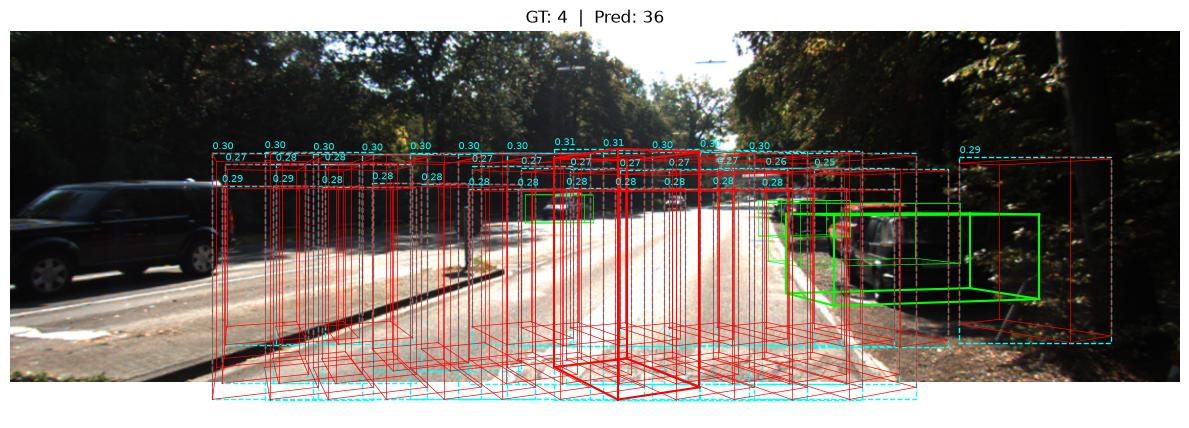

In [13]:
# --- Example usage ---
idx = 1
image = batch["image"][idx:idx+1].cuda()
gt_boxes = batch["boxes_3d"][idx].cuda()
K_b = batch["K"][idx].cuda()

with torch.inference_mode():
    feats = model(image)
    results = probe(feats, targets=None, K=K_b.unsqueeze(0))
    pred_boxes = results[0]["boxes_3d"]
    pred_scores = results[0]["scores"]

draw_boxes_simple(image[0], gt_boxes=gt_boxes,
                  pred_boxes=pred_boxes, K=K_b,
                  scores=pred_scores)

In [14]:
# --- Run inference on one sample ---
idx = 3
image = batch["image"][idx:idx+1].cuda()           # (1, 3, H, W)
K     = batch["K"][idx].cuda()                      # (3, 3)
gt    = batch["boxes_3d"][idx].cuda()               # (N, 7)

d_boxes = batch["boxes_2d"][idx].cuda()             # (N, 4)

with torch.inference_mode():
    feats = model(image)
    orient, conf, dim = probe(feats, [d_boxes])     # Geometric3DProbe
    box_list = [d_boxes[i] for i in range(len(d_boxes))]
    K_list = [K] * len(d_boxes)
    pred_boxes, scores, labels = probe.decode_boxes(orient, conf, dim, box_list, K_list)

draw_boxes(image[0], gt, pred_boxes, K)

ValueError: not enough values to unpack (expected 3, got 1)

## Class-wise Analysis
Number of instances, AP, and average GT vs Predicted volume per class.

In [ ]:
import tqdm
import numpy as np
from collections import defaultdict
from evals.utils.metrics import evaluate_box3d, evaluate_aos, _compute_iou3d
from evals.utils.losses import OrientationLoss, build_orientation_target

CLASS_NAMES = {0: "Car", 1: "Pedestrian", 2: "Cyclist"}

def validate_classwise(model, probe, loader, verbose=True):
    """Run validation and collect per-class predictions & GTs for class-wise AP."""
    probe.eval()

    class_gt_boxes   = defaultdict(list)  # cls -> list of (7,) tensors
    class_pred_boxes = defaultdict(list)  # cls -> list of (7,) tensors
    class_pred_scores= defaultdict(list)  # cls -> list of scores

    with torch.inference_mode():
        pbar = tqdm.tqdm(loader, desc="Validation") if verbose else loader
        i= 0
        for batch in pbar:
            images = batch["image"].cuda()
            boxes_3d_list = batch["boxes_3d"]
            boxes_2d_list = batch["boxes_2d"]
            labels_list = batch["labels"]
            K_batch = batch["K"].cuda()

            feats = model(images)
            if isinstance(feats, (tuple, list)):
                feats = feats[0] if len(feats) == 1 else feats[-1]

            orient, conf, dim = probe(feats, boxes_2d_list)

            for b in range(images.size(0)):
                if len(boxes_3d_list[b]) == 0:
                    continue

                N_prev = sum(len(boxes_2d_list[j]) for j in range(b))
                N_cur  = len(boxes_2d_list[b])
                idx = slice(N_prev, N_prev + N_cur)

                orient_b = orient[idx]
                conf_b   = conf[idx]
                dim_b    = dim[idx]

                box_2d_tensors = [boxes_2d_list[b][n] for n in range(N_cur)]
                K_tensors      = [K_batch[b]] * N_cur
                obj_labels_t   = labels_list[b].to(orient.device)

                # GT orientation bins
                true_bins = []
                for n in range(N_cur):
                    box_3d = boxes_3d_list[b][n]
                    box_2d = boxes_2d_list[b][n]
                    K = K_batch[b]
                    theta = box_3d[6]
                    u_center = (box_2d[0] + box_2d[2]) / 2.0
                    theta_ray = torch.atan2(u_center - K[0, 2], K[0, 0])
                    alpha_gt = theta - theta_ray
                    alpha_gt = torch.atan2(torch.sin(alpha_gt), torch.cos(alpha_gt))
                    _, cg = build_orientation_target(alpha_gt.unsqueeze(0), bins=probe.bins)
                    true_bins.append(cg.argmax(dim=1).item())
                true_argmax = torch.tensor(true_bins, device=orient.device)

                boxes_3d_pred, scores, _ = probe.decode_boxes(
                    orient_b, conf_b, dim_b, box_2d_tensors, K_tensors,
                    labels=obj_labels_t, true_argmax=true_argmax)

                # Per-class collection
                for n in range(N_cur):
                    cls = obj_labels_t[n].item()
                    class_gt_boxes[cls].append(boxes_3d_list[b][n])
                    class_pred_boxes[cls].append(boxes_3d_pred[n])
                    class_pred_scores[cls].append(scores[n])
            i+=1
            if i>100:
                break    
    # --- Aggregate class-wise ---
    results = {}
    for cls in sorted(class_gt_boxes.keys()):
        gt_all    = torch.stack(class_gt_boxes[cls]).cuda()
        pred_all  = torch.stack(class_pred_boxes[cls]).cuda()
        scores_all= torch.stack(class_pred_scores[cls]).cuda()

        ap = evaluate_box3d(pred_all, scores_all, gt_all, iou_thresholds=[0.1, 0.3])

        gt_vol   = (gt_all[:, 3]   * gt_all[:, 4]   * gt_all[:, 5]).cpu().numpy()
        pred_vol = (pred_all[:, 3] * pred_all[:, 4] * pred_all[:, 5]).cpu().numpy()

        results[cls] = {
            "name":          CLASS_NAMES.get(cls, f"cls_{cls}"),
            "num_instances": len(gt_all),
            "ap_0.1":        ap["ap_3d_0.1"],
            "ap_0.3":        ap["ap_3d_0.3"],
            "center_err":    ap.get("center_err", float("nan")),
            "dim_err":       ap.get("dim_err", float("nan")),
            "yaw_err":       ap.get("yaw_err", float("nan")),
            "avg_gt_vol":    float(gt_vol.mean()),
            "avg_pred_vol":  float(pred_vol.mean()),
        }

    return results

Validation:   0%|          | 3/943 [00:04<21:21,  1.36s/it]

Validation:  11%|█         | 100/943 [02:14<18:52,  1.34s/it]
/home/akashmanna/ws/probe3d/evals/utils/metrics.py:442: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(inter_area / union_area)


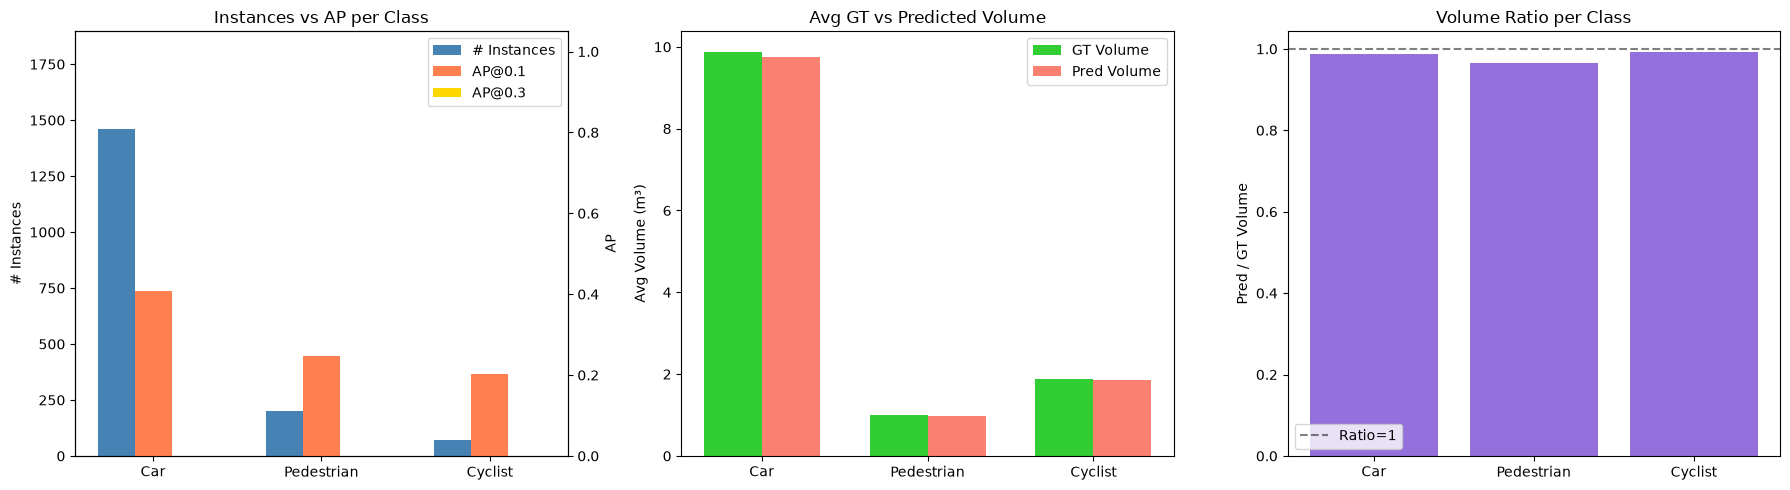

Class        | #Inst | AP@0.1 AP@0.3 |  GT_vol Pred_vol |  Center    Dim    Yaw
------------------------------------------------------------------------------------------
Car          |  1459 |  0.408  0.000 |    9.89     9.75 |   0.897  0.177  1.038
Pedestrian   |   201 |  0.247  0.000 |    1.01     0.97 |   0.402  0.127  0.777
Cyclist      |    70 |  0.201  0.000 |    1.87     1.86 |   0.652  0.093  0.411


In [ ]:
# --- Run class-wise validation ---
results = validate_classwise(model, probe, valid_loader)

# --- Prepare data ---
classes      = [results[c]["name"] for c in sorted(results.keys())]
n_instances  = [results[c]["num_instances"] for c in sorted(results.keys())]
ap_01        = [results[c]["ap_0.1"] for c in sorted(results.keys())]
ap_03        = [results[c]["ap_0.3"] for c in sorted(results.keys())]
avg_gt_vol   = [results[c]["avg_gt_vol"] for c in sorted(results.keys())]
avg_pred_vol = [results[c]["avg_pred_vol"] for c in sorted(results.keys())]

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(classes))

# 1) Instances vs AP
w = 0.22
axes[0].bar(x - w, n_instances, w, label="# Instances", color="steelblue", zorder=2)
ax0t = axes[0].twinx()
ax0t.bar(x, ap_01, w, label="AP@0.1", color="coral", zorder=2)
ax0t.bar(x + w, ap_03, w, label="AP@0.3", color="gold", zorder=2)
axes[0].set_xticks(x); axes[0].set_xticklabels(classes)
axes[0].set_ylabel("# Instances"); ax0t.set_ylabel("AP")
axes[0].set_ylim(0, max(n_instances) * 1.3 if n_instances else 1)
ax0t.set_ylim(0, 1.05)
h1, l1 = axes[0].get_legend_handles_labels()
h2, l2 = ax0t.get_legend_handles_labels()
axes[0].legend(h1 + h2, l1 + l2, loc="upper right")
axes[0].set_title("Instances vs AP per Class")

# 2) Avg GT vs Pred Volume
w = 0.35
axes[1].bar(x - w/2, avg_gt_vol, w, label="GT Volume", color="limegreen")
axes[1].bar(x + w/2, avg_pred_vol, w, label="Pred Volume", color="salmon")
axes[1].set_xticks(x); axes[1].set_xticklabels(classes)
axes[1].set_ylabel("Avg Volume (m³)")
axes[1].set_title("Avg GT vs Predicted Volume")
axes[1].legend()

# 3) Pred/GT Volume Ratio
vol_ratio = [p / g if g > 0 else 0 for p, g in zip(avg_pred_vol, avg_gt_vol)]
axes[2].bar(x, vol_ratio, color="mediumpurple")
axes[2].axhline(1.0, color="black", linestyle="--", alpha=0.5, label="Ratio=1")
axes[2].set_xticks(x); axes[2].set_xticklabels(classes)
axes[2].set_ylabel("Pred / GT Volume")
axes[2].set_title("Volume Ratio per Class")
axes[2].legend()

plt.tight_layout()
plt.show()

# --- Print summary ---
print(f"{'Class':12s} | {'#Inst':>5s} | {'AP@0.1':>6s} {'AP@0.3':>6s} | "
      f"{'GT_vol':>7s} {'Pred_vol':>8s} | {'Center':>7s} {'Dim':>6s} {'Yaw':>6s}")
print("-" * 90)
for c in sorted(results.keys()):
    r = results[c]
    ce = r["center_err"] if not np.isnan(r["center_err"]) else 0.0
    de = r["dim_err"] if not np.isnan(r["dim_err"]) else 0.0
    ye = r["yaw_err"] if not np.isnan(r["yaw_err"]) else 0.0
    print(f"{r['name']:12s} | {r['num_instances']:5d} | "
          f"{r['ap_0.1']:6.3f} {r['ap_0.3']:6.3f} | "
          f"{r['avg_gt_vol']:7.2f} {r['avg_pred_vol']:8.2f} | "
          f"{ce:7.3f} {de:6.3f} {ye:6.3f}")

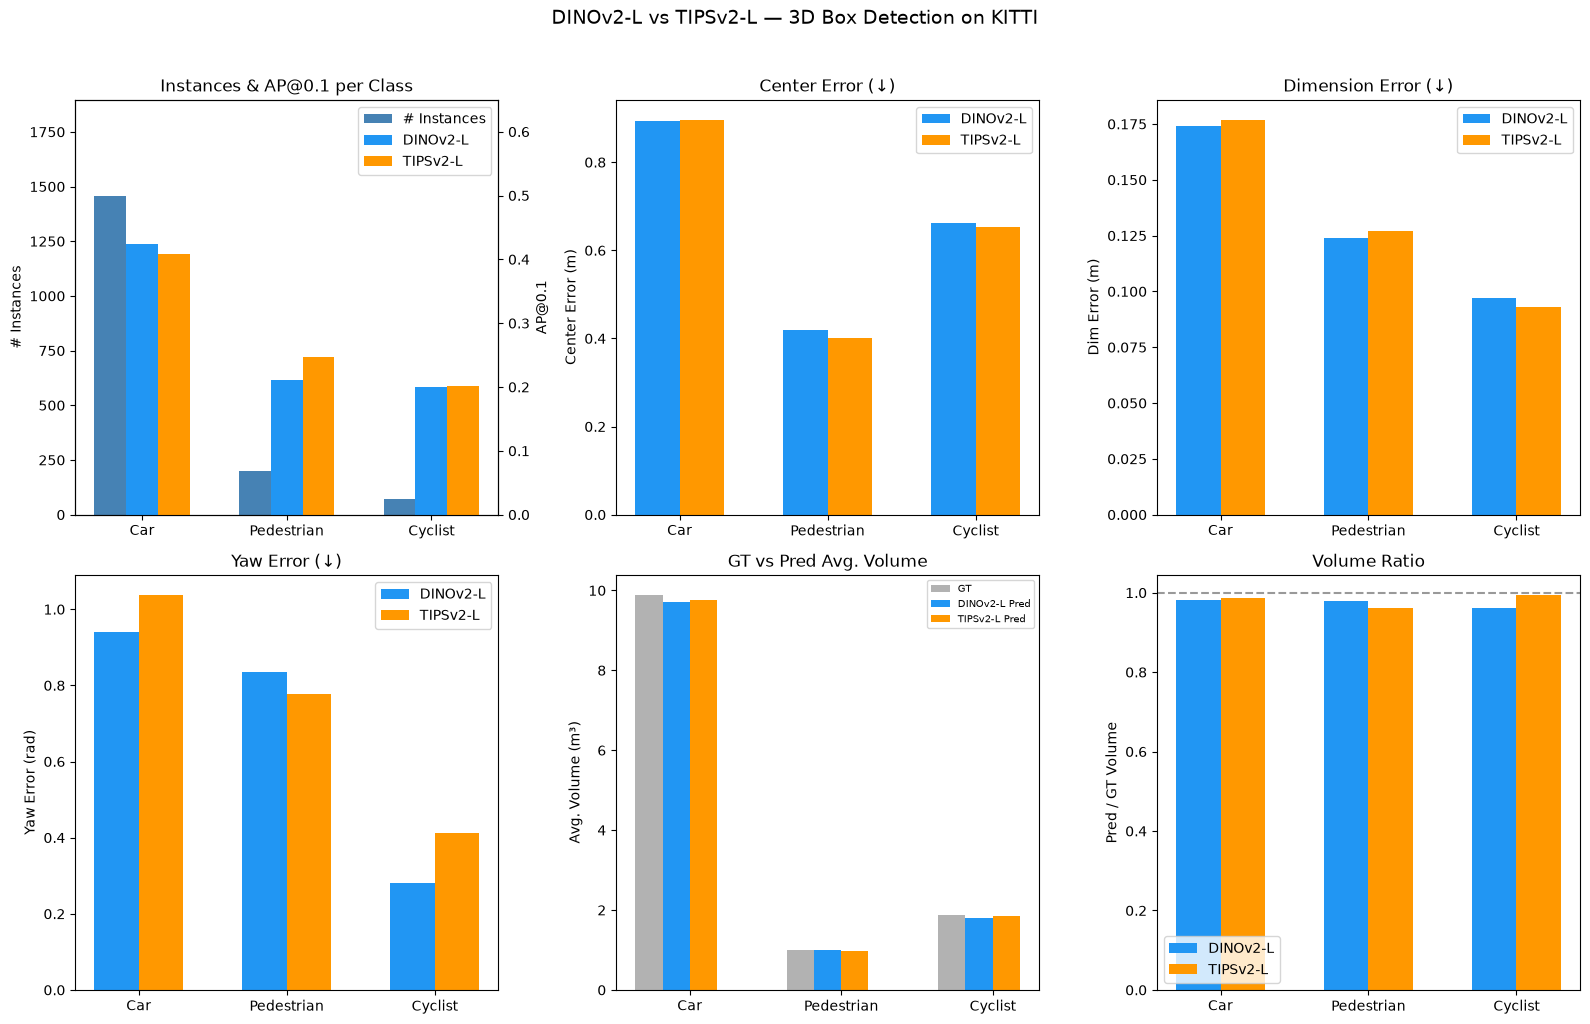

In [ ]:
# --- DINOv2-L vs TIPSv2-L Comparison ---
import numpy as np
import matplotlib.pyplot as plt

classes = ["Car", "Pedestrian", "Cyclist"]
n_instances = [1459, 201, 70]  # same for both

# DINOv2-L results (from run)
dinov2 = {
    "ap_01":      [0.424, 0.211, 0.200],
    "center_err": [0.893, 0.420, 0.662],
    "dim_err":    [0.174, 0.124, 0.097],
    "yaw_err":    [0.941, 0.834, 0.281],
    "gt_vol":     [9.89,  1.01,  1.87],
    "pred_vol":   [9.70,  0.99,  1.80],
}

# TIPSv2-L results (from run)
tipsv2 = {
    "ap_01":      [0.408, 0.247, 0.201],
    "center_err": [0.897, 0.402, 0.652],
    "dim_err":    [0.177, 0.127, 0.093],
    "yaw_err":    [1.038, 0.777, 0.411],
    "gt_vol":     [9.89,  1.01,  1.87],
    "pred_vol":   [9.75,  0.97,  1.86],
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
x = np.arange(len(classes))
w = 0.22
w2 = 0.30
colors = ["#2196F3", "#FF9800"]  # blue=DINOv2, orange=TIPSv2

# Row 1: AP@0.1 + Instances, Center Error, Dim Error
# --- AP@0.1 + # Instances (dual axis) ---
axes[0, 0].bar(x - w, n_instances, w, label="# Instances", color="steelblue", zorder=2)
ax0t = axes[0, 0].twinx()
ax0t.bar(x, dinov2["ap_01"], w, label="DINOv2-L", color=colors[0], zorder=2)
ax0t.bar(x + w, tipsv2["ap_01"], w, label="TIPSv2-L", color=colors[1], zorder=2)
axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels(classes)
axes[0, 0].set_ylabel("# Instances"); ax0t.set_ylabel("AP@0.1")
axes[0, 0].set_ylim(0, max(n_instances) * 1.3)
ax0t.set_ylim(0, 0.65)
h1, l1 = axes[0, 0].get_legend_handles_labels()
h2, l2 = ax0t.get_legend_handles_labels()
axes[0, 0].legend(h1 + h2, l1 + l2, loc="upper right")
axes[0, 0].set_title("Instances & AP@0.1 per Class")

# --- Center Error (lower is better) ---
axes[0, 1].bar(x - w2/2, dinov2["center_err"], w2, label="DINOv2-L", color=colors[0])
axes[0, 1].bar(x + w2/2, tipsv2["center_err"], w2, label="TIPSv2-L", color=colors[1])
axes[0, 1].set_xticks(x); axes[0, 1].set_xticklabels(classes)
axes[0, 1].set_ylabel("Center Error (m)"); axes[0, 1].set_title("Center Error (↓)")
axes[0, 1].legend()

# --- Dim Error (lower is better) ---
axes[0, 2].bar(x - w2/2, dinov2["dim_err"], w2, label="DINOv2-L", color=colors[0])
axes[0, 2].bar(x + w2/2, tipsv2["dim_err"], w2, label="TIPSv2-L", color=colors[1])
axes[0, 2].set_xticks(x); axes[0, 2].set_xticklabels(classes)
axes[0, 2].set_ylabel("Dim Error (m)"); axes[0, 2].set_title("Dimension Error (↓)")
axes[0, 2].legend()

# Row 2: Yaw Error, GT vs Pred Volume, Volume Ratio
# --- Yaw Error (lower is better) ---
axes[1, 0].bar(x - w2/2, dinov2["yaw_err"], w2, label="DINOv2-L", color=colors[0])
axes[1, 0].bar(x + w2/2, tipsv2["yaw_err"], w2, label="TIPSv2-L", color=colors[1])
axes[1, 0].set_xticks(x); axes[1, 0].set_xticklabels(classes)
axes[1, 0].set_ylabel("Yaw Error (rad)"); axes[1, 0].set_title("Yaw Error (↓)")
axes[1, 0].legend()

# --- GT vs Pred Volume ---
w3 = 0.18
for i, cls in enumerate(classes):
    axes[1, 1].bar(i - 1.5*w3, dinov2["gt_vol"][i], w3, color="gray", alpha=0.6,
                   label="GT" if i == 0 else "")
    axes[1, 1].bar(i - 0.5*w3, dinov2["pred_vol"][i], w3, color=colors[0],
                   label="DINOv2-L Pred" if i == 0 else "")
    axes[1, 1].bar(i + 0.5*w3, tipsv2["pred_vol"][i], w3, color=colors[1],
                   label="TIPSv2-L Pred" if i == 0 else "")
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(classes)
axes[1, 1].set_ylabel("Avg. Volume (m³)"); axes[1, 1].set_title("GT vs Pred Avg. Volume")
axes[1, 1].legend(fontsize=7)

# --- Volume Ratio (Pred/GT) ---
dinov2_ratio = [p/g for p, g in zip(dinov2["pred_vol"], dinov2["gt_vol"])]
tipsv2_ratio = [p/g for p, g in zip(tipsv2["pred_vol"], tipsv2["gt_vol"])]
axes[1, 2].bar(x - w2/2, dinov2_ratio, w2, label="DINOv2-L", color=colors[0])
axes[1, 2].bar(x + w2/2, tipsv2_ratio, w2, label="TIPSv2-L", color=colors[1])
axes[1, 2].axhline(1.0, color="black", linestyle="--", alpha=0.4)
axes[1, 2].set_xticks(x); axes[1, 2].set_xticklabels(classes)
axes[1, 2].set_ylabel("Pred / GT Volume"); axes[1, 2].set_title("Volume Ratio")
axes[1, 2].legend()

plt.suptitle("DINOv2-L vs TIPSv2-L — 3D Box Detection on KITTI", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()